# Cuff-less Blood Pressure Data Preprocessing

This notebook preprocesses the UCI Cuff-less Blood Pressure dataset for blood pressure estimation using PPG signals.

The preprocessing steps include loading the MATLAB v7.3 data, separating PPG and ABP signals, checking for invalid values, creating 5-second windows, extracting systolic and diastolic blood pressure labels, checking for potential outliers, and normalizing the PPG signals.

In [26]:
import h5py
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

## Load the Dataset

The dataset is stored as a MATLAB v7.3 file and is loaded using `h5py`. Part 1 of the dataset contains 3,000 physiological signal records.

In [27]:
file = h5py.File("../data/part_1.mat", "r")
data = file["Part_1"]

print("Number of records in Part_1:", data.shape[0])

Number of records in Part_1: 3000


## Preprocess All Records

Each record contains PPG and ABP signals sampled at 125 Hz. The signals are divided into 5-second windows, giving 625 samples per window.

For each window, peaks and valleys in the ABP signal are used to estimate systolic and diastolic blood pressure. The corresponding PPG window is normalized using z-score normalization. Windows with invalid data, missing peaks or valleys, or flat PPG signals are skipped.

In [28]:
all_ppg_windows = []
all_abp_windows = []
all_systolic_labels = []
all_diastolic_labels = []

window_size = 625

invalid_records = 0
flat_ppg_windows = 0
no_peak_windows = 0

for i in range(data.shape[0]):

    record_ref = data[i, 0]
    record = np.array(file[record_ref])

    ppg = record[:, 0]
    abp = record[:, 1]

    # Skip records with invalid values
    if not np.all(np.isfinite(ppg)) or not np.all(np.isfinite(abp)):
        invalid_records += 1
        continue

    # Create 5-second windows
    for start in range(0, len(ppg) - window_size + 1, window_size):

        end = start + window_size

        ppg_window = ppg[start:end]
        abp_window = abp[start:end]

        # Find ABP peaks and valleys
        peaks, _ = find_peaks(abp_window, distance=50)
        valleys, _ = find_peaks(-abp_window, distance=50)

        if len(peaks) == 0 or len(valleys) == 0:
            no_peak_windows += 1
            continue

        # Calculate blood pressure labels
        systolic = np.mean(abp_window[peaks])
        diastolic = np.mean(abp_window[valleys])

        # Normalize PPG
        ppg_mean = np.mean(ppg_window)
        ppg_std = np.std(ppg_window)

        if ppg_std == 0:
            flat_ppg_windows += 1
            continue

        normalized_ppg = (ppg_window - ppg_mean) / ppg_std

        # Store matching data
        all_ppg_windows.append(normalized_ppg)
        all_abp_windows.append(abp_window)
        all_systolic_labels.append(systolic)
        all_diastolic_labels.append(diastolic)

## Convert Processed Data

The valid PPG windows, ABP windows, and blood pressure labels are converted to NumPy arrays for analysis and later use in machine learning.

In [29]:
all_ppg_windows = np.array(all_ppg_windows)
all_abp_windows = np.array(all_abp_windows)
all_systolic_labels = np.array(all_systolic_labels)
all_diastolic_labels = np.array(all_diastolic_labels)

## Preprocessing Results

In [30]:
print("Records processed:", data.shape[0])
print("Invalid records skipped:", invalid_records)
print("Flat PPG windows skipped:", flat_ppg_windows)
print("Windows without peaks/valleys:", no_peak_windows)

print("\nTotal valid examples:", len(all_ppg_windows))

print("PPG dataset shape:", all_ppg_windows.shape)
print("ABP dataset shape:", all_abp_windows.shape)
print("Systolic labels shape:", all_systolic_labels.shape)
print("Diastolic labels shape:", all_diastolic_labels.shape)

Records processed: 3000
Invalid records skipped: 0
Flat PPG windows skipped: 0
Windows without peaks/valleys: 1

Total valid examples: 131162
PPG dataset shape: (131162, 625)
ABP dataset shape: (131162, 625)
Systolic labels shape: (131162,)
Diastolic labels shape: (131162,)


## Blood Pressure Range and Outlier Check

The systolic and diastolic labels are checked to understand their overall ranges and identify potentially unusual values. Extreme values are flagged for investigation rather than automatically removed because they may represent real physiological measurements.

In [31]:
print("Lowest systolic:", np.min(all_systolic_labels))
print("Highest systolic:", np.max(all_systolic_labels))

print("Lowest diastolic:", np.min(all_diastolic_labels))
print("Highest diastolic:", np.max(all_diastolic_labels))

print("\nExtreme BP labels:")

print("Systolic below 70:",
      np.sum(all_systolic_labels < 70))

print("Systolic above 180:",
      np.sum(all_systolic_labels > 180))

print("Diastolic below 40:",
      np.sum(all_diastolic_labels < 40))

print("Diastolic above 120:",
      np.sum(all_diastolic_labels > 120))

Lowest systolic: 59.51550603419474
Highest systolic: 197.98589439468398
Lowest diastolic: 50.0
Highest diastolic: 188.11641319808058

Extreme BP labels:
Systolic below 70: 9
Systolic above 180: 2117
Diastolic below 40: 0
Diastolic above 120: 382


### Blood Pressure Findings

Across the processed Part 1 data, systolic labels ranged from approximately 59.52 to 197.99 mmHg and diastolic labels ranged from 50.00 to 188.12 mmHg.

There were 9 systolic labels below 70 mmHg, 2,117 above 180 mmHg, and 382 diastolic labels above 120 mmHg. These values were flagged as potentially unusual but were not automatically removed because additional investigation of the ABP waveforms is needed to determine whether they represent real measurements or noisy data.

## Blood Pressure Distribution

The distributions of the systolic and diastolic blood pressure labels are visualized using histograms. This helps show where most blood pressure values are concentrated and whether extreme values appear frequently in the dataset.

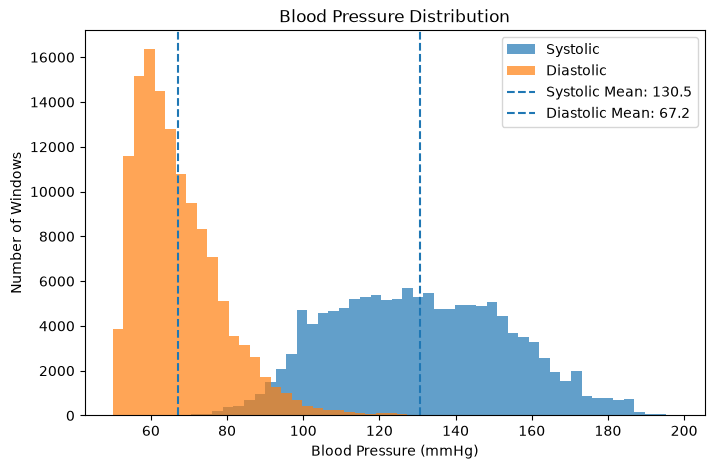

Systolic mean: 130.54410997140653
Systolic standard deviation: 22.97104023208118
Diastolic mean: 67.21795946317776
Diastolic standard deviation: 11.598520883360093


In [35]:
plt.figure(figsize=(8, 5))

# Calculate mean and standard deviation
sbp_mean = np.mean(all_systolic_labels)
sbp_std = np.std(all_systolic_labels)

dbp_mean = np.mean(all_diastolic_labels)
dbp_std = np.std(all_diastolic_labels)

# Histograms
plt.hist(all_systolic_labels, bins=50, alpha=0.7, label="Systolic")
plt.hist(all_diastolic_labels, bins=50, alpha=0.7, label="Diastolic")

# Mean lines
plt.axvline(sbp_mean, linestyle="--",
            label=f"Systolic Mean: {sbp_mean:.1f}")

plt.axvline(dbp_mean, linestyle="--",
            label=f"Diastolic Mean: {dbp_mean:.1f}")

plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Number of Windows")
plt.title("Blood Pressure Distribution")
plt.legend()

plt.show()

print("Systolic mean:", sbp_mean)
print("Systolic standard deviation:", sbp_std)

print("Diastolic mean:", dbp_mean)
print("Diastolic standard deviation:", dbp_std)

In [36]:
print("First window mean:",
      np.mean(all_ppg_windows[0]))

print("First window standard deviation:",
      np.std(all_ppg_windows[0]))

First window mean: 7.105427357601002e-17
First window standard deviation: 1.0
